Будем осуществлять работу с непростым набором данных “horse_data.csv” о состоянии здоровья лошадей, испытывающих кишечные колики. Цель – максимально корректно заполнить пропуски.
### Задание 1. Загрузка данных
Изучить представленный набор данных на основе описания его столбцов в файле “horse_data.names” , загрузить его и оставить 8 столбцов для дальнейшего изучения: surgery?, Age, rectal temperature, pulse, respiratory rate, temperature of extremities, pain, outcome.

In [1]:
import pandas as pd

# import warnings
# warnings.filterwarnings('ignore')

df = pd.read_csv('horse_data.csv', header=None, na_values='?')
# открыв датафрейм увидел что ? вместо пропусков, заменил их na_values='?' на NaN

df.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2


In [2]:
# .iloc[:, :8] извлекает из df[:'это все строки дата фрейма', :8 'извлекли первые 8 (колонки: 0, 1,..., 7'] и потом придется переименоввывать колонки еще.
df_short = df.iloc[:, :9]

In [3]:
df_short.columns = ['surgery', 'age', 'hospital_number',  'rectal temperature', 'pulse', 'respiratory rate', 'temperature of extremities', 'pain', 'outcome']
df_short.iloc[50:100] # для просмотра большой выборки не по 10строк

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
50,2.0,1,529766,38.6,46.0,NaN,1.0,1.0,2.0
51,1.0,1,527706,37.4,84.0,36.0,1.0,NaN,3.0
52,2.0,1,529483,NaN,NaN,NaN,1.0,1.0,3.0
53,2.0,1,530544,38.6,40.0,20.0,NaN,NaN,NaN
54,2.0,1,529461,40.3,114.0,36.0,3.0,3.0,1.0
55,1.0,9,5282839,38.6,160.0,20.0,3.0,NaN,5.0
56,1.0,1,528872,NaN,NaN,NaN,NaN,NaN,NaN
57,1.0,1,529640,NaN,64.0,36.0,2.0,NaN,2.0
58,1.0,1,528298,NaN,NaN,20.0,4.0,3.0,3.0
59,2.0,1,528904,NaN,96.0,NaN,3.0,3.0,3.0


In [4]:
df_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   surgery                     299 non-null    float64
 1   age                         300 non-null    int64  
 2   hospital_number             300 non-null    int64  
 3   rectal temperature          240 non-null    float64
 4   pulse                       276 non-null    float64
 5   respiratory rate            242 non-null    float64
 6   temperature of extremities  244 non-null    float64
 7   pain                        231 non-null    float64
 8   outcome                     253 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 21.2 KB


### Задание 2. Первичное изучение данных
Проанализировать значения по столбцам, рассчитать базовые статистики, найти выбросы.

In [5]:
df_short.describe()

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
count,299.000000,300.000000,3.000000e+02,240.000000,276.000000,242.000000,244.000000,231.000000,253.000000
mean,1.397993,1.640000,1.085889e+06,38.167917,71.913043,30.417355,2.348361,2.017316,2.853755
std,0.490305,2.173972,1.529801e+06,0.732289,28.630557,17.642231,1.045054,1.042428,1.620294
min,1.000000,1.000000,5.184760e+05,35.400000,30.000000,8.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,5.289040e+05,37.800000,48.000000,18.500000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,5.303055e+05,38.200000,64.000000,24.500000,3.000000,2.000000,3.000000
75%,2.000000,1.000000,5.347275e+05,38.500000,88.000000,36.000000,3.000000,3.000000,4.000000
max,2.000000,9.000000,5.305629e+06,40.800000,184.000000,96.000000,4.000000,4.000000,6.000000


Я буду искать выбросы через IQR

In [6]:
# просто в ручную искать выбросы так для того чтобы попробовать:

print('Данные по столбцу: ' + 'rectal temperature')

q1 = df_short['rectal temperature'].quantile(0.25)
q3 = df_short['rectal temperature'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# print(len(df_short[~df_short['rectal temperature'].between(lower_bound, upper_bound, inclusive='both')]))
print(df_short[~df_short['pulse'].between(lower_bound, upper_bound, inclusive='both')])

Данные по столбцу: rectal temperature
     surgery  age  hospital_number  rectal temperature  pulse  \
0        2.0    1           530101                38.5   66.0   
1        1.0    1           534817                39.2   88.0   
2        2.0    1           530334                38.3   40.0   
3        1.0    9          5290409                39.1  164.0   
4        2.0    1           530255                37.3  104.0   
..       ...  ...              ...                 ...    ...   
295      1.0    1           533886                 NaN  120.0   
296      2.0    1           527702                37.2   72.0   
297      1.0    1           529386                37.5   72.0   
298      1.0    1           530612                36.5  100.0   
299      1.0    1           534618                37.2   40.0   

     respiratory rate  temperature of extremities  pain  outcome  
0                28.0                         3.0   3.0      NaN  
1                20.0                         N

In [7]:
# т.к. я не хотел писать много строк кода, я решил написать функцию
# если понадобиться ф-ция которая будет выводить и выбросы и норм значения, нужно будет создать флаг, и в зависимости от флага добавить условие и реализацию
def get_normal_mask(data, column):
    '''
    данная функция выводит нормальные значения без выбросов:
    на вход идут 2 параметра:
     1. data - это датафрейм;
     2. column - нужная колонка;
    '''
    # 1. Расчёт границ:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # 2. Базовая маска для НОРМАЛЬНЫХ значений (True) (inclusive='both' включая границы)
    return data[column].between(lower_bound, upper_bound, inclusive='both')

в учебном примере мы избавлялись только от выбросов в одной колонке.
поэтому погуглив я нашел решение, что нам нужно избавляться от выбросов, только там где у нас непрерывные величины, такие как температура, рост итд.
поэтому я убрал выбросы в трех столбцах и работал дальше с ними(в столбце температуры конечностей лошади, где значения от 1 до 4 думаю выбросов нет), чтобы сделать один датафрейм.
не совсем понимаю насколько это правильно

In [8]:
# Получаем нормальные маски для каждого столбца
mask_temp = get_normal_mask(df_short, 'rectal temperature')
mask_pulse = get_normal_mask(df_short, 'pulse')
mask_resp = get_normal_mask(df_short, 'respiratory rate')

In [9]:
# Объединяем их! Строка останется, только если ВСЕ три маски дали True.
# При этом пропуски (NaN) оставляем, работа с ними будет в 3 части
# (вспоминаем, что для NaN метод .between() выдает False, лекция, поэтому принудительно возвращаем их через .isnull() ИЛИ .isn() )
# складываем через "ИЛИ" маску | пропуск в каждой строке, и потом совместно проверяем по непрерывным значениям.
# Значение ИЛИ NaN, если ни то ни другое скипаемстроку. так у трех масок
final_mask = ((mask_temp | df_short['rectal temperature'].isnull()) &
              (mask_pulse | df_short['pulse'].isnull()) &
              (mask_resp | df_short['respiratory rate'].isnull()))

In [10]:
# собираем в кучу получившийся датафрейм из условий выше
df_no_outliers = df_short[final_mask]
df_no_outliers

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0
5,2.0,1,528355,NaN,NaN,NaN,2.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...
293,1.0,1,534004,NaN,78.0,24.0,3.0,3.0,3.0
294,2.0,1,533902,38.5,40.0,16.0,1.0,1.0,1.0
296,2.0,1,527702,37.2,72.0,24.0,3.0,2.0,4.0
297,1.0,1,529386,37.5,72.0,30.0,4.0,3.0,4.0


In [11]:
# основная стата изменилась из-за изменения количества строк с отсутствием выбросов
df_no_outliers.describe()
# статистика немного изменилась, тк у нас были удалены выбросы, а где-то в этих строках были значения not NaN и медиана напремер уменьшилась по пульсу

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
count,266.000000,267.000000,2.670000e+02,209.000000,243.000000,212.000000,216.000000,206.000000,223.000000
mean,1.413534,1.389513,9.763612e+05,38.133971,68.164609,26.202830,2.333333,1.966019,2.838565
std,0.493395,1.724972,1.388505e+06,0.559914,24.604593,11.206438,1.047700,1.047092,1.591345
min,1.000000,1.000000,5.184760e+05,36.800000,30.000000,8.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,5.289310e+05,37.800000,48.000000,17.500000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,5.302970e+05,38.100000,60.000000,24.000000,3.000000,1.000000,3.000000
75%,2.000000,1.000000,5.346210e+05,38.500000,86.000000,32.000000,3.000000,3.000000,4.000000
max,2.000000,9.000000,5.305629e+06,39.500000,136.000000,60.000000,4.000000,4.000000,6.000000


### Задание 3. Работа с пропусками
Рассчитать количество пропусков для всех выбранных столбцов. Принять и обосновать решение о методе заполнения пропусков по каждому столбцу на основе рассчитанных статистик и возможной взаимосвязи значений в них. Сформировать датафрейм, в котором пропуски будут отсутствовать.

In [12]:
# здесь я пытался посмотреть наглядно более широкие выборки нежели по несколько значений, чтобы попытаться создать взаимосвязи между величинами
# df_no_outliers.tail(50)
# df_no_outliers.head(50)

In [13]:
# 1. Получаем маску нормальных значений для пульса/дыхания итд,
# просто разное для наглядности смотрел, чтобы искать на датафрейме выше, для поиска связей
mask_pulse = get_normal_mask(df_short, 'surgery')

# 2. Переворачиваем её с помощью ~ (теперь True — это выбросы)
outliers_pulse = df_short[~mask_pulse]

# 3. Выводим только этот столбец, чтобы увидеть сами значения выбросов
print(outliers_pulse['surgery'])

132   NaN
Name: surgery, dtype: float64


In [14]:
# процент пропусков, чтобы думать насколько критично, возможно придется отбрасывать столбцы при большой потере данных
(df_no_outliers.isna().mean() * 100).round(2)

surgery                        0.37
age                            0.00
hospital_number                0.00
rectal temperature            21.72
pulse                          8.99
respiratory rate              20.60
temperature of extremities    19.10
pain                          22.85
outcome                       16.48
dtype: float64

тк у нас нет столбцов с пропусками более 30-50% мы все оставляем и работаем с ними

In [15]:
# количество пропусков по каждому столбцу после удаления выбросов; пропусков стало меньше, тк какие-то строки убрали
df_no_outliers.isnull().sum()

surgery                        1
age                            0
hospital_number                0
rectal temperature            58
pulse                         24
respiratory rate              55
temperature of extremities    51
pain                          61
outcome                       44
dtype: int64

In [16]:
# оставлять только те строки в которых нет пропусков не рационально, тк датафрейм уменьшится почти в 2 раза было 266 rows стало 124
# df_no_outliers.dropna(thresh=9)

### Работаем с пропусками surgery:
('pain')['surgery']

- здесь у нас связь между типом лечения и болью

In [17]:
# Показать строки, где в столбце surgery именно пропуск
df_short[df_short['surgery'].isnull()]

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
132,NaN,1,534572,38.0,48.0,20.0,3.0,1.0,3.0


In [18]:
# группируем по боли и выводим показатели, среднего, моды, медианы по "surgery"
print(df_no_outliers.groupby('pain')['surgery'].agg(['mean', 'median', lambda x: x.mode()[0]]))
'''
возможно пропуск допущен случайно MCAR, тк он один. поэтому делая вывод из выборки показателей

у нас пропуск с  уровнем боли "pain" = 1, я буду заменять 'surgery' медианное значение для этой групп

"pain" = 1 => 'surgery' преобладает = 2
'''

          mean  median  <lambda_0>
pain                              
1.0   1.551402     2.0         2.0
2.0   1.800000     2.0         2.0
3.0   1.282353     1.0         1.0
4.0   1.250000     1.0         1.0


'\nвозможно пропуск допущен случайно MCAR, тк он один. поэтому делая вывод из выборки показателей\n\nу нас пропуск с  уровнем боли "pain" = 1, я буду заменять \'surgery\' медианное значение для этой групп\n\n"pain" = 1 => \'surgery\' преобладает = 2\n'

In [19]:
# # производим замену:
# # 1.создаем копию датафрейма
# df_filled = df_no_outliers.copy()
# # 2. в столбце surgery заменяем пропуск на значение 2 для наглядности для себя
# df_filled['surgery'] = df_filled['surgery'].fillna(2)
# df_filled.loc[[132]]

# эта вариант замены через метод transform берет медиану каждой группы и в зависимости от группы подставляет нужное значение автоматом
df_filled = df_no_outliers.copy()
df_filled['surgery'] = df_filled['surgery'].fillna(
    df_no_outliers.groupby('pain')['surgery'].transform('median')
)
df_filled.loc[[132]]
#значение заменили наглядно видно ниже

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
132,2.0,1,534572,38.0,48.0,20.0,3.0,1.0,3.0


### Работаем с пропусками "rectal temperature":
('temperature of extremities')['rectal temperature']
- когда внутреннрие органы наливаются кровью, происходит отток от конечностей и уменьшение температуры

In [20]:
# df_short[df_short['rectal temperature'].isnull()]

In [21]:
# тк выше мы сформировали связь между показателями "rectal temperature" и "temperature of extremities"
# аналогично будем проводить замещение по данным группам

print(df_no_outliers.groupby('temperature of extremities')['rectal temperature'].agg(
    ['mean', 'median', lambda x: x.mode()[0]]
)
)

df_filled['rectal temperature'] = df_filled['rectal temperature'].fillna(
    df_no_outliers.groupby('temperature of extremities')['rectal temperature'].transform('median')
)

                                 mean  median  <lambda_0>
temperature of extremities                               
1.0                         38.089062   38.10        37.8
2.0                         38.112500   38.15        38.6
3.0                         38.163636   38.10        38.0
4.0                         38.444444   38.35        37.5


### Работаем с пропусками "pulse":
('pain')['pulse']
- также у животного из-за шокового состояния от боли, может увелшичиваться пульс

In [22]:
print(df_no_outliers.groupby('pain')['pulse'].agg(
    ['mean', 'median', lambda x: x.mode()[0]]
)
)

# тоже работаю с медианой, тк она устойчива и мульс в целых значениях только
df_filled['pulse'] = df_filled['pulse'].fillna(
    df_no_outliers.groupby('pain')['pulse'].transform('median')
)

           mean  median  <lambda_0>
pain                               
1.0   55.823529    50.0        48.0
2.0   59.200000    60.0        40.0
3.0   86.532468    88.0        96.0
4.0   91.428571    88.0        70.0


### Работаем с пропусками "respiratory rate":
('pain')['respiratory rate']

- увеличение пусьса , увеличение стресса, увеличение количество вдохов но связь не прям явная

In [23]:
print(df_no_outliers.groupby('pain')['respiratory rate'].agg(['mean', 'median']))

# тоже работаю с медианой, тк она устойчива и мульс в целых значениях только
df_filled['respiratory rate'] = df_filled['respiratory rate'].fillna(
    df_no_outliers.groupby('pain')['respiratory rate'].transform('median')
)

           mean  median
pain                   
1.0   23.225806    21.0
2.0   30.666667    32.0
3.0   30.859375    30.0
4.0   31.666667    26.0


### Работаем с пропусками "pain":
('surgery')['pain']
- из-за метода лечения у нас связь с болью

In [24]:
# Смотрим, какая боль (мода) чаще всего бывает у тех, кому делали операцию и у тех, кому нет
print(df_no_outliers.groupby('surgery')['pain'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None))

surgery
1.0    3.0
2.0    1.0
Name: pain, dtype: float64


In [25]:
# Заполняем пропуски в боли (pain) модой на основе того, была ли операция (surgery)
df_filled['pain'] = df_filled['pain'].fillna(
    df_no_outliers.groupby('surgery')['pain'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

### Работаем с пропусками "outcome":
('pain')['outcome']
- исход зависит от боли, животное может умереть например от боли, это один из явных признаков

In [26]:
print(
    df_filled.groupby(['surgery', 'pain'])['outcome'].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else None
    )
)

surgery  pain
1.0      1.0     1.0
         2.0     2.0
         3.0     3.0
         4.0     4.0
2.0      1.0     1.0
         2.0     1.0
         3.0     4.0
         4.0     3.0
Name: outcome, dtype: float64


In [27]:
# замена по моде
df_filled['outcome'] = df_filled['outcome'].fillna(
    df_no_outliers.groupby('pain')['outcome'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

### Работаем с пропусками "temperature of extremities":
('pulse')['temperature of extremities']

- учащение пульса, прилив крови к важным органам, конечности остывают

In [28]:
print(df_no_outliers.groupby('pulse')['temperature of extremities'].agg(['mean', 'median', lambda x: x.mode()[0] if not x.mode().empty else None]))

           mean  median  <lambda_0>
pulse                              
30.0        NaN     NaN         NaN
36.0   1.666667     1.0         1.0
38.0   3.000000     3.0         3.0
40.0   1.666667     1.0         1.0
42.0   1.800000     2.0         1.0
44.0   2.272727     3.0         3.0
45.0   2.500000     2.5         2.0
46.0   1.000000     1.0         1.0
48.0   1.863636     1.0         1.0
49.0        NaN     NaN         NaN
50.0   2.000000     2.0         1.0
52.0   1.300000     1.0         1.0
54.0   1.666667     1.5         1.0
56.0   2.000000     2.0         1.0
60.0   2.454545     3.0         3.0
64.0   1.500000     1.0         1.0
65.0        NaN     NaN         NaN
66.0   1.666667     1.0         1.0
68.0   2.333333     2.0         2.0
70.0   2.333333     3.0         3.0
72.0   2.857143     3.0         4.0
75.0        NaN     NaN         NaN
76.0   2.000000     2.0         1.0
78.0   3.000000     3.0         3.0
80.0   3.142857     3.0         3.0
82.0   3.000000     3.0     

In [29]:
df_filled['temperature of extremities'] = df_filled['temperature of extremities'].fillna(
    df_no_outliers.groupby('pulse')['temperature of extremities'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

In [30]:
# df_filled.dropna(thresh=9)

### Будем дозаполнять менее явными признаки тк остались пропуски:
по оставшимся критериям. возможно между ними есть связь, но чтобы это понять нужно проверить корреляцию и много чего сделать, поэтому принимаю тот факт, что признаки ниже менее явны но могут влиять друг на друга

#### outcome:

In [31]:
# Смотрим зависимость
print("Зависимость от surgery:")
print(df_no_outliers.groupby('surgery')['outcome'].agg([lambda x: x.mode()[0] if not x.mode().empty else None]))

# Сразу заполняем
df_filled['outcome'] = df_filled['outcome'].fillna(
    df_no_outliers.groupby('surgery')['outcome'].transform(lambda x: x.mode()[0])
)

Зависимость от surgery:
         <lambda>
surgery          
1.0           3.0
2.0           1.0


In [32]:
# Смотрим зависимость
print("Зависимость от age:")
print(df_no_outliers.groupby('age')['outcome'].agg([lambda x: x.mode()[0] if not x.mode().empty else None]))

# Сразу заполняем
df_filled['outcome'] = df_filled['outcome'].fillna(
    df_no_outliers.groupby('age')['outcome'].transform(lambda x: x.mode()[0])
)

Зависимость от age:
     <lambda>
age          
1         1.0
9         2.0


In [33]:
# Смотрим зависимость
print("Зависимость от pain:")
print(df_no_outliers.groupby('pain')['outcome'].agg([lambda x: x.mode()[0] if not x.mode().empty else None]))

# Сразу заполняем
df_filled['outcome'] = df_filled['outcome'].fillna(
    df_no_outliers.groupby('pain')['outcome'].transform(lambda x: x.mode()[0])
)

Зависимость от pain:
      <lambda>
pain          
1.0        1.0
2.0        2.0
3.0        4.0
4.0        4.0


#### 'respiratory rate':

In [34]:
# Смотрим зависимость
print("Медиана дыхания по исходу (outcome):")
print(df_no_outliers.groupby('outcome')['respiratory rate'].agg(['count', 'mean', 'median', lambda x: x.mode()[0] if not x.mode().empty else None]))

# Сразу заполняем
df_filled['respiratory rate'] = df_filled['respiratory rate'].fillna(
    df_no_outliers.groupby('outcome')['respiratory rate'].transform('median')
)

Медиана дыхания по исходу (outcome):
         count       mean  median  <lambda_0>
outcome                                      
1.0         56  21.125000    19.0        16.0
2.0         24  26.666667    23.0        20.0
3.0         44  28.159091    30.0        12.0
4.0         33  27.575758    28.0        30.0
5.0         14  26.571429    22.0        16.0
6.0         11  35.909091    35.0        40.0


In [35]:
# Смотрим зависимость
print("Медиана дыхания по исходу (pulse):")
print(df_no_outliers.groupby('pulse')['respiratory rate'].agg(['count', 'mean', 'median', lambda x: x.mode()[0] if not x.mode().empty else None]))

# Сразу заполняем
df_filled['respiratory rate'] = df_filled['respiratory rate'].fillna(
    df_no_outliers.groupby('pulse')['respiratory rate'].transform('median')
)

Медиана дыхания по исходу (pulse):
       count       mean  median  <lambda_0>
pulse                                      
30.0       2  15.000000    15.0        12.0
36.0       3  19.000000    16.0         9.0
38.0       1  20.000000    20.0        20.0
40.0      16  19.437500    17.0        16.0
42.0       7  23.714286    24.0        10.0
44.0      11  18.000000    14.0        12.0
45.0       2  14.000000    14.0        12.0
46.0       0        NaN     NaN         NaN
48.0      24  21.666667    20.0        20.0
49.0       0        NaN     NaN         NaN
50.0       6  29.000000    32.0        32.0
52.0      10  20.000000    20.0        16.0
54.0       5  27.600000    24.0        24.0
56.0       4  27.000000    26.0        16.0
60.0      20  26.850000    26.0        20.0
64.0       6  30.833333    32.0        36.0
65.0       1  24.000000    24.0        24.0
66.0       6  19.333333    20.0        12.0
68.0       5  23.600000    20.0        20.0
70.0       4  22.500000    19.0        16

In [36]:
# Смотрим зависимость
print("Медиана дыхания по исходу (age):")
print(df_no_outliers.groupby('age')['respiratory rate'].agg(['count', 'mean', 'median', lambda x: x.mode()[0] if not x.mode().empty else None]))

# Сразу заполняем
df_filled['respiratory rate'] = df_filled['respiratory rate'].fillna(
    df_no_outliers.groupby('age')['respiratory rate'].transform('median')
)

Медиана дыхания по исходу (age):
     count       mean  median  <lambda_0>
age                                      
1      202  25.618812    24.0        20.0
9       10  38.000000    36.0        28.0


#### 'rectal temperature':

In [37]:
# Смотрим зависимость от боли
print("Медиана ректальной температуры по уровню боли (pain):")
print(df_no_outliers.groupby('pain')['rectal temperature'].agg(['count', 'mean', 'median']))

# Заполняем по уровню боли
df_filled['rectal temperature'] = df_filled['rectal temperature'].fillna(
    df_no_outliers.groupby('pain')['rectal temperature'].transform('median')
)

# Добираем остатки по исходу (outcome)
df_filled['rectal temperature'] = df_filled['rectal temperature'].fillna(
    df_no_outliers.groupby('outcome')['rectal temperature'].transform('median')
)

print(f"Осталось пропусков в rectal temperature: {df_filled['rectal temperature'].isna().sum()}")

Медиана ректальной температуры по уровню боли (pain):
      count       mean  median
pain                          
1.0      99  38.103030   38.10
2.0       5  38.000000   38.10
3.0      60  38.183333   38.20
4.0       2  39.250000   39.25
Осталось пропусков в rectal temperature: 11


#### 'temperature of extremities':

In [38]:
# Смотрим моду по исходу
print("Самая частая температура конечностей по исходу (outcome):")
print(df_no_outliers.groupby('outcome')['temperature of extremities'].agg([lambda x: x.mode()[0] if not x.mode().empty else 1.0]))

# Заполняем по исходу
df_filled['temperature of extremities'] = df_filled['temperature of extremities'].fillna(
    df_no_outliers.groupby('outcome')['temperature of extremities'].transform(lambda x: x.mode()[0] if not x.mode().empty else 1.0)
)

print(f"Осталось пропусков в temperature of extremities: {df_filled['temperature of extremities'].isna().sum()}")

Самая частая температура конечностей по исходу (outcome):
         <lambda>
outcome          
1.0           1.0
2.0           1.0
3.0           1.0
4.0           3.0
5.0           3.0
6.0           3.0
Осталось пропусков в temperature of extremities: 12


#### 'pulse':

проверирим что творится с пульсом, тк у нас по остальным позициям не так много пропусков осталось

In [39]:
# Выводим строки с пропущенным пульсом, показывая ключевые признаки для анализа
missing_pulse_df = df_filled[df_filled['pulse'].isna()]

print(f"Всего строк с пропущенным пульсом: {len(missing_pulse_df)}")
missing_pulse_df

Всего строк с пропущенным пульсом: 9


,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
28,1.0,1,5279442,NaN,NaN,24.0,NaN,3.0,3.0
56,1.0,1,528872,NaN,NaN,24.0,NaN,3.0,3.0
74,1.0,9,5292929,NaN,NaN,36.0,NaN,3.0,3.0
160,1.0,1,527916,NaN,NaN,24.0,NaN,3.0,3.0
175,1.0,1,527929,NaN,NaN,24.0,NaN,3.0,3.0
207,1.0,1,530297,NaN,NaN,24.0,NaN,3.0,3.0
216,2.0,1,528977,NaN,NaN,24.0,NaN,1.0,1.0
227,1.0,9,5289419,NaN,NaN,36.0,NaN,3.0,3.0
288,1.0,1,529428,NaN,NaN,24.0,NaN,3.0,3.0


In [40]:
print(df_no_outliers.groupby('age').count())

     surgery  hospital_number  rectal temperature  pulse  respiratory rate  \
age                                                                          
1        253              254                 200    232               202   
9         13               13                   9     11                10   

     temperature of extremities  pain  outcome  
age                                             
1                           208   198      215  
9                             8     8        8  


так, здесь у нас почти все данные пропущены, коней с возрастогм age = 1 мы удаляем, а коней, возраст к-ых у нас 9, будем заполнять, т.к. их количество в общей выборке малое. это 15%-20% выборки старых коней

In [41]:
# 1. Считаем чистые медианы именно для коней (age == 9) из исходного df_no_outliers
foal_pulse = df_no_outliers[df_no_outliers['age'] == 9]['pulse'].median()
foal_temp = df_no_outliers[df_no_outliers['age'] == 9]['rectal temperature'].median()
foal_ext = df_no_outliers[df_no_outliers['age'] == 9]['temperature of extremities'].mode()[0]
print(foal_pulse, foal_temp, foal_ext)

100.0 38.4 3.0


In [42]:
# 2. Точечно заполняем пропуски в df_filled ТОЛЬКО для жеребят
df_filled.loc[(df_filled['pulse'].isna()) & (df_filled['age'] == 9), 'pulse'] = foal_pulse
df_filled.loc[(df_filled['rectal temperature'].isna()) & (df_filled['age'] == 9), 'rectal temperature'] = foal_temp
df_filled.loc[(df_filled['temperature of extremities'].isna()) & (df_filled['age'] == 9), 'temperature of extremities'] = foal_ext

# здесь у нас произошло заполнение других столбцов кроме пульса, на 2 соответствующих столбцов

In [43]:
# 3. оставшиеся 7 строк для коней (где age == 1 и всё пусто) дропаем
df_filled = df_filled.dropna(subset=['pulse'])

#### две температуры оставщихся:

In [44]:
df_filled[df_filled['rectal temperature'].isna()]

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
87,2.0,1,528006,NaN,40.0,16.0,1.0,1.0,1.0
169,1.0,1,535085,NaN,65.0,24.0,NaN,3.0,3.0


In [45]:
print(df_no_outliers.groupby('pain')['rectal temperature'].agg(['count', 'mean', 'median', lambda x: x.mode()[0] if not x.mode().empty else None]))

df_filled['rectal temperature'] = df_filled['rectal temperature'].fillna(
    df_no_outliers.groupby('pain')['rectal temperature'].transform('median')
)

      count       mean  median  <lambda_0>
pain                                      
1.0      99  38.103030   38.10        38.0
2.0       5  38.000000   38.10        37.2
3.0      60  38.183333   38.20        38.5
4.0       2  39.250000   39.25        39.2


In [46]:
# ищем медианы глобальные для температур по боли
pain_temperature_medians = df_no_outliers.groupby('pain')['rectal temperature'].median()


print(pain_temperature_medians)

# 2. Заполняем пропуски в df_filled, подтягивая медиану по значению столбца 'pain'
df_filled['rectal temperature'] = df_filled['rectal temperature'].fillna(
    df_filled['pain'].map(pain_temperature_medians)
)

# проверяем
print(df_filled[df_filled['rectal temperature'].isna()])

pain
1.0    38.10
2.0    38.10
3.0    38.20
4.0    39.25
Name: rectal temperature, dtype: float64
Empty DataFrame
Columns: [surgery, age, hospital_number, rectal temperature, pulse, respiratory rate, temperature of extremities, pain, outcome]
Index: []


In [47]:
df_filled[df_filled['temperature of extremities'].isna()]

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
130,1.0,1,528964,37.8,30.0,12.0,NaN,3.0,3.0
169,1.0,1,535085,38.2,65.0,24.0,NaN,3.0,3.0
232,1.0,1,5262543,38.5,30.0,18.0,NaN,3.0,3.0


In [48]:
# смотрим на значения:
print(df_no_outliers.groupby('pain')['temperature of extremities'].agg(['count', 'mean', 'median', lambda x: x.mode()[0] if not x.mode().empty else None]))

      count      mean  median  <lambda_0>
pain                                     
1.0     102  1.784314     1.0         1.0
2.0       5  1.800000     2.0         1.0
3.0      79  3.037975     3.0         3.0
4.0       8  3.375000     3.0         3.0


In [49]:
# смотрим на значения:
# print(df_no_outliers.groupby('pain')['temperature of extremities'].agg(['count', 'mean', 'median', lambda x: x.mode()[0] if not x.mode().empty else None]))

# расчитывем для температуры конечностей 'temperature of extremities' по 'pain'
pain_temperature_mod = df_no_outliers.groupby('pain')['temperature of extremities'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 1.0)

print(pain_temperature_mod) # смотрим

# 2. Заполняем пропуски в df_filled, подтягивая моду по значению столбца 'pain'
df_filled['temperature of extremities'] = df_filled['temperature of extremities'].fillna(
    df_filled['pain'].map(pain_temperature_mod)
)

# проверяем пропуски
print(df_filled[df_filled['temperature of extremities'].isna()])

pain
1.0    1.0
2.0    1.0
3.0    3.0
4.0    3.0
Name: temperature of extremities, dtype: float64
Empty DataFrame
Columns: [surgery, age, hospital_number, rectal temperature, pulse, respiratory rate, temperature of extremities, pain, outcome]
Index: []


In [50]:
df_finish = df_filled
df_finish

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
0,2.0,1,530101,38.50,66.0,28.0,3.0,3.0,4.0
1,1.0,1,534817,39.20,88.0,20.0,3.0,3.0,4.0
2,2.0,1,530334,38.30,40.0,24.0,1.0,1.0,3.0
4,2.0,1,530255,37.30,104.0,35.0,3.0,1.0,6.0
5,2.0,1,528355,38.15,50.0,21.0,2.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...
293,1.0,1,534004,38.10,78.0,24.0,3.0,3.0,3.0
294,2.0,1,533902,38.50,40.0,16.0,1.0,1.0,1.0
296,2.0,1,527702,37.20,72.0,24.0,3.0,2.0,4.0
297,1.0,1,529386,37.50,72.0,30.0,4.0,3.0,4.0


In [51]:
df_finish.isnull().sum()

surgery                       0
age                           0
hospital_number               0
rectal temperature            0
pulse                         0
respiratory rate              0
temperature of extremities    0
pain                          0
outcome                       0
dtype: int64

In [52]:
df_finish.info()

<class 'pandas.core.frame.DataFrame'>
Index: 260 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   surgery                     260 non-null    float64
 1   age                         260 non-null    int64  
 2   hospital_number             260 non-null    int64  
 3   rectal temperature          260 non-null    float64
 4   pulse                       260 non-null    float64
 5   respiratory rate            260 non-null    float64
 6   temperature of extremities  260 non-null    float64
 7   pain                        260 non-null    float64
 8   outcome                     260 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 20.3 KB


### Мы избавились от выбросов, а теперь нужно проверить изменения стат.показателей:


In [53]:
df_finish.describe()

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
count,260.000000,260.000000,2.600000e+02,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,1.423077,1.400000,9.701368e+05,38.136154,68.676923,26.250000,2.292308,2.026923,2.796154
std,0.495000,1.746922,1.379813e+06,0.503713,24.382954,10.327597,1.061405,1.037542,1.544946
min,1.000000,1.000000,5.184760e+05,36.800000,30.000000,8.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,5.289558e+05,37.900000,48.000000,20.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,5.303145e+05,38.100000,60.000000,24.000000,3.000000,2.000000,3.000000
75%,2.000000,1.000000,5.346245e+05,38.400000,88.000000,32.000000,3.000000,3.000000,4.000000
max,2.000000,9.000000,5.305629e+06,39.500000,136.000000,60.000000,4.000000,4.000000,6.000000


In [54]:
df_short.describe()

,surgery,age,hospital_number,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
count,299.000000,300.000000,3.000000e+02,240.000000,276.000000,242.000000,244.000000,231.000000,253.000000
mean,1.397993,1.640000,1.085889e+06,38.167917,71.913043,30.417355,2.348361,2.017316,2.853755
std,0.490305,2.173972,1.529801e+06,0.732289,28.630557,17.642231,1.045054,1.042428,1.620294
min,1.000000,1.000000,5.184760e+05,35.400000,30.000000,8.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,5.289040e+05,37.800000,48.000000,18.500000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,5.303055e+05,38.200000,64.000000,24.500000,3.000000,2.000000,3.000000
75%,2.000000,1.000000,5.347275e+05,38.500000,88.000000,36.000000,3.000000,3.000000,4.000000
max,2.000000,9.000000,5.305629e+06,40.800000,184.000000,96.000000,4.000000,4.000000,6.000000


In [55]:
print(df_finish['rectal temperature'].describe() - df_short['rectal temperature'].describe())
print('-' * 30 )
print(df_finish['pulse'].describe() - df_short['pulse'].describe())
print('-' * 30 )
print(df_finish['respiratory rate'].describe() - df_short['respiratory rate'].describe())
print('-' * 30 )
print(df_finish['temperature of extremities'].describe() - df_short['temperature of extremities'].describe())
print('-' * 30 )
print(df_finish['pain'].describe() - df_short['pain'].describe())
print('-' * 30 )
print(df_finish['outcome'].describe() - df_short['outcome'].describe())

count    20.000000
mean     -0.031763
std      -0.228576
min       1.400000
25%       0.100000
50%      -0.100000
75%      -0.100000
max      -1.300000
Name: rectal temperature, dtype: float64
------------------------------
count   -16.000000
mean     -3.236120
std      -4.247603
min       0.000000
25%       0.000000
50%      -4.000000
75%       0.000000
max     -48.000000
Name: pulse, dtype: float64
------------------------------
count    18.000000
mean     -4.167355
std      -7.314634
min       0.000000
25%       1.500000
50%      -0.500000
75%      -4.000000
max     -36.000000
Name: respiratory rate, dtype: float64
------------------------------
count    16.000000
mean     -0.056053
std       0.016352
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.000000
Name: temperature of extremities, dtype: float64
------------------------------
count    29.000000
mean      0.009607
std      -0.004886
min       0.000000
25%       0.000000
50%       0.0000

дальше так чисто посмотреть что с данными

C:\Users\fokin\AppData\Local\Temp\ipykernel_20376\2445190257.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_short['pulse'], label='Исходные данные (с пропусками и выбросами)', color='red', shade=True)
C:\Users\fokin\AppData\Local\Temp\ipykernel_20376\2445190257.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_finish['pulse'], label='Финальные данные (чистые)', color='green', shade=True)


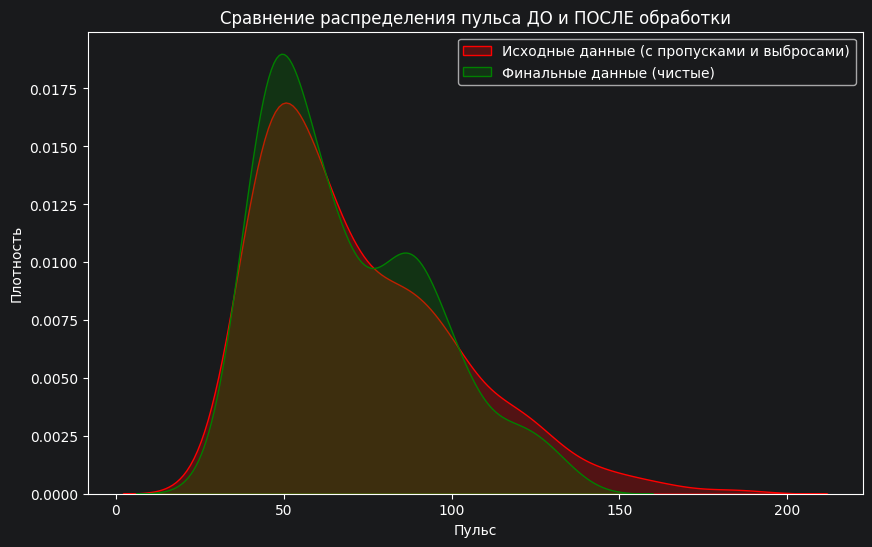

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Рисуем исходное распределение (до чистки пропусков и выбросов)
sns.kdeplot(df_short['pulse'], label='Исходные данные (с пропусками и выбросами)', color='red', shade=True)

# Рисуем финальное распределение
sns.kdeplot(df_finish['pulse'], label='Финальные данные (чистые)', color='green', shade=True)

plt.title('Сравнение распределения пульса ДО и ПОСЛЕ обработки')
plt.xlabel('Пульс')
plt.ylabel('Плотность')
plt.legend()
plt.show()

In [57]:
# Выбираем числовые столбцы для проверки
check_cols = ['pulse', 'respiratory rate', 'rectal temperature']

for col in check_cols:
    old_median = df_short[col].median()
    new_median = df_filled[col].median()

    # Считаем процент изменения
    pct_change = abs(old_median - new_median) / old_median * 100

    print(f"Столбец '{col}':")
    print(f"  Была медиана: {old_median} -> Стала: {new_median}")
    print(f"  Изменение: {pct_change:.2f}%")
    if pct_change > 10:
        print("  ⚠️ Внимание: сдвиг больше 10%, проверь логику!")
    else:
        print("  ✅ Всё отлично, изменения в пределах нормы.")
    print("-" * 40)

Столбец 'pulse':
  Была медиана: 64.0 -> Стала: 60.0
  Изменение: 6.25%
  ✅ Всё отлично, изменения в пределах нормы.
----------------------------------------
Столбец 'respiratory rate':
  Была медиана: 24.5 -> Стала: 24.0
  Изменение: 2.04%
  ✅ Всё отлично, изменения в пределах нормы.
----------------------------------------
Столбец 'rectal temperature':
  Была медиана: 38.2 -> Стала: 38.1
  Изменение: 0.26%
  ✅ Всё отлично, изменения в пределах нормы.
----------------------------------------
